# Deep Q Learning - AirRaid - Inference and Visualization

In [4]:
"""
Setup Script for Air Raid DQN
"""

# Step 1: Install required packages
print("Installing required packages...")
print("="*60)

# Install gymnasium with Atari support
!pip install --user -q gymnasium[atari]
!pip install --user -q gymnasium[accept-rom-license]

# Alternative: Install ale-py directly
!pip install --user -q ale-py

# Install AutoROM for Atari ROMs (includes Air Raid)
!pip install --user -q autorom[accept-rom-license]

# Accept Atari ROM license and download ROMs
print("\nAccepting Atari ROM license and downloading ROMs...")
!AutoROM --accept-license

print("\n" + "="*60)
print("Installation complete!")
print("="*60)

# Step 2: Verify installation
print("\nVerifying installation...")
try:
    import gymnasium as gym
    from ale_py import ALEInterface
    print("✓ gymnasium installed")
    print("✓ ale-py installed")
    
    # Check if ALE namespace is available
    try:
        env = gym.make('ALE/AirRaid-v5', frameskip=1)
        print("✓ ALE/AirRaid-v5 environment available")
        print(f"  Action space: {env.action_space}")
        print(f"  Observation space: {env.observation_space}")
        env.close()
    except Exception as e:
        print(f"✗ Error creating environment: {e}")
        print("\nTrying alternative environment name...")
        try:
            env = gym.make('AirRaid-v5', frameskip=1)
            print("✓ AirRaid-v5 environment available (without ALE prefix)")
            env.close()
        except Exception as e2:
            print(f"✗ Also failed: {e2}")
    
except ImportError as e:
    print(f"✗ Import error: {e}")
    print("\nPlease restart the kernel and run this cell again.")

# Step 3: Import other dependencies
print("\nImporting other dependencies...")
import torch
import numpy as np
import matplotlib.pyplot as plt
from PIL import Image
print("✓ All dependencies imported successfully")

# Step 4: Check GPU availability
print(f"\nGPU Available: {torch.cuda.is_available()}")
if torch.cuda.is_available():
    print(f"GPU Device: {torch.cuda.get_device_name(0)}")
    print(f"GPU Memory: {torch.cuda.get_device_properties(0).total_memory / 1e9:.2f} GB")
else:
    print("Running on CPU (will be slower)")

print("\n" + "="*60)
print("Setup complete! You can now run the DQN code.")
print("="*60)

Installing required packages...

[notice] A new release of pip is available: 25.2 -> 25.3
[notice] To update, run: pip install --upgrade pip

[notice] A new release of pip is available: 25.2 -> 25.3
[notice] To update, run: pip install --upgrade pip

[notice] A new release of pip is available: 25.2 -> 25.3
[notice] To update, run: pip install --upgrade pip

[notice] A new release of pip is available: 25.2 -> 25.3
[notice] To update, run: pip install --upgrade pip

Accepting Atari ROM license and downloading ROMs...
/bin/bash: line 1: AutoROM: command not found

Installation complete!

Verifying installation...
✓ gymnasium installed
✓ ale-py installed
✓ ALE/AirRaid-v5 environment available
  Action space: Discrete(6)
  Observation space: Box(0, 255, (250, 160, 3), uint8)

Importing other dependencies...
✓ All dependencies imported successfully

GPU Available: True
GPU Device: NVIDIA H200
GPU Memory: 150.12 GB

Setup complete! You can now run the DQN code.


A.L.E: Arcade Learning Environment (version 0.11.2+ecc1138)
[Powered by Stella]


In [5]:
import gymnasium as gym
import numpy as np
import torch
import torch.nn as nn
import torch.nn.functional as F
import matplotlib.pyplot as plt
from IPython.display import clear_output
import time
import cv2
from collections import deque, namedtuple
import random
from PIL import Image

%matplotlib inline

In [6]:
# Set device
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print(f"Using device: {device}")

Experience = namedtuple('Experience', ['state', 'action', 'reward', 'next_state', 'done'])

class FramePreprocessor:
    """Preprocess Atari frames for DQN."""
    
    def __init__(self, height=84, width=84):
        self.height = height
        self.width = width
    
    def preprocess(self, frame):
        """Preprocess a single frame."""
        # Convert to grayscale
        if len(frame.shape) == 3:
            gray = np.dot(frame[..., :3], [0.299, 0.587, 0.114])
        else:
            gray = frame
        
        # Resize to 84x84
        img = Image.fromarray(gray.astype(np.uint8))
        img = img.resize((self.width, self.height), Image.BILINEAR)
        
        # Normalize to [0, 1]
        processed = np.array(img, dtype=np.float32) / 255.0
        
        return processed


class FrameStack:
    """Stack k consecutive frames."""
    
    def __init__(self, k=4):
        self.k = k
        self.frames = deque(maxlen=k)
    
    def reset(self):
        self.frames.clear()
    
    def push(self, frame):
        self.frames.append(frame)
        while len(self.frames) < self.k:
            self.frames.append(frame)
    
    def get_state(self):
        return np.stack(self.frames, axis=0)


class ReplayBuffer:
    """Experience Replay Buffer."""
    
    def __init__(self, capacity=50000):  # Reduced for Kaggle
        self.buffer = deque(maxlen=capacity)
    
    def push(self, state, action, reward, next_state, done):
        self.buffer.append(Experience(state, action, reward, next_state, done))
    
    def sample(self, batch_size):
        experiences = random.sample(self.buffer, batch_size)
        
        states = torch.FloatTensor(np.array([e.state for e in experiences])).to(device)
        actions = torch.LongTensor([e.action for e in experiences]).to(device)
        rewards = torch.FloatTensor([e.reward for e in experiences]).to(device)
        next_states = torch.FloatTensor(np.array([e.next_state for e in experiences])).to(device)
        dones = torch.FloatTensor([e.done for e in experiences]).to(device)
        
        return states, actions, rewards, next_states, dones
    
    def __len__(self):
        return len(self.buffer)


class DQN(nn.Module):
    """Deep Q-Network with CNN architecture."""
    
    def __init__(self, n_frames=4, n_actions=6):
        super(DQN, self).__init__()
        
        self.conv1 = nn.Conv2d(n_frames, 32, kernel_size=8, stride=4)
        self.conv2 = nn.Conv2d(32, 64, kernel_size=4, stride=2)
        self.conv3 = nn.Conv2d(64, 64, kernel_size=3, stride=1)
        
        # Calculate conv output size
        def conv2d_size_out(size, kernel_size, stride):
            return (size - kernel_size) // stride + 1
        
        h = conv2d_size_out(conv2d_size_out(conv2d_size_out(84, 8, 4), 4, 2), 3, 1)
        w = conv2d_size_out(conv2d_size_out(conv2d_size_out(84, 8, 4), 4, 2), 3, 1)
        conv_output_size = h * w * 64
        
        self.fc1 = nn.Linear(conv_output_size, 512)
        self.fc2 = nn.Linear(512, n_actions)
    
    def forward(self, x):
        x = F.relu(self.conv1(x))
        x = F.relu(self.conv2(x))
        x = F.relu(self.conv3(x))
        x = x.reshape(x.size(0), -1)
        x = F.relu(self.fc1(x))
        q_values = self.fc2(x)
        return q_values



def create_environment():
    """Create Air Raid environment with fallback options."""
    env_names = [
        'ALE/AirRaid-v5',
        'AirRaid-v5',
        'ALE/AirRaid-v4',
        'AirRaid-v4'
    ]
    
    for env_name in env_names:
        try:
            print(f"Trying to create environment: {env_name}")
            env = gym.make(env_name, frameskip=4)
            print(f"✓ Successfully created: {env_name}")
            print(f"  Action space: {env.action_space}")
            print(f"  Observation space: {env.observation_space}")
            return env
        except Exception as e:
            print(f"✗ Failed: {e}")
            continue
    
    raise RuntimeError("Could not create Air Raid environment. Please run the setup cell first.")




Using device: cuda


In [7]:
# ============================================================================
# LOAD MODEL
# ============================================================================
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print(f"Using device: {device}\n")

# Create environment
env = gym.make('ALE/AirRaid-v5', render_mode='rgb_array')
action_meanings = env.unwrapped.get_action_meanings()

# MODEL PATH
MODEL_PATH = 'high_alpha_agent.pth'  

# Load model
checkpoint = torch.load(MODEL_PATH, map_location=device)
model = DQN(n_frames=4, n_actions=env.action_space.n).to(device)
model.load_state_dict(checkpoint['policy_net'])
model.eval()

print(f"✓ Model loaded: {MODEL_PATH}")
print(f"  Action space: {env.action_space.n} actions")
print(f"  Actions: {action_meanings}\n")

Using device: cuda



/tmp/ipykernel_1144525/657130775.py:15: FutureWarning: You are using `torch.load` with `weights_only=False` (the current default value), which uses the default pickle module implicitly. It is possible to construct malicious pickle data which will execute arbitrary code during unpickling (See https://github.com/pytorch/pytorch/blob/main/SECURITY.md#untrusted-models for more details). In a future release, the default value for `weights_only` will be flipped to `True`. This limits the functions that could be executed during unpickling. Arbitrary objects will no longer be allowed to be loaded via this mode unless they are explicitly allowlisted by the user via `torch.serialization.add_safe_globals`. We recommend you start setting `weights_only=True` for any use case where you don't have full control of the loaded file. Please open an issue on GitHub for any issues related to this experimental feature.
  checkpoint = torch.load(MODEL_PATH, map_location=device)


✓ Model loaded: high_alpha_agent.pth
  Action space: 6 actions
  Actions: ['NOOP', 'FIRE', 'RIGHT', 'LEFT', 'RIGHTFIRE', 'LEFTFIRE']



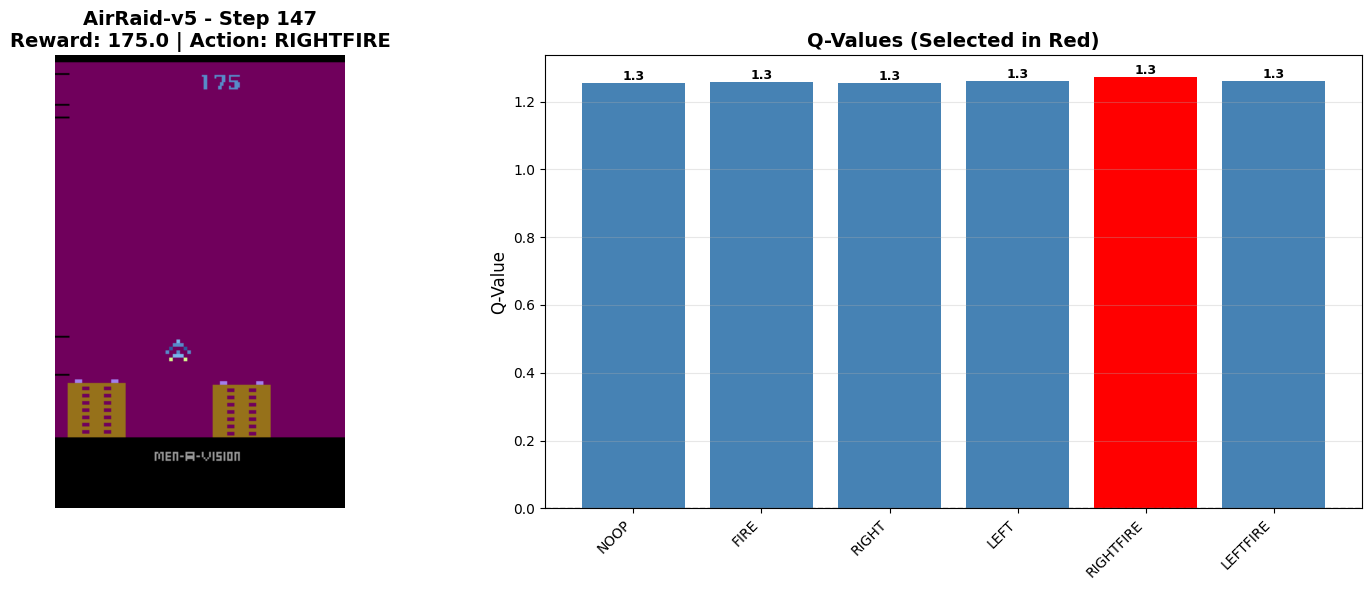


EPISODE COMPLETE!
Total Reward: 175.0
Episode Length: 147 steps
Avg Reward/Step: 1.190


In [8]:
# ============================================================================
# PLAY AND VISUALIZE
# ============================================================================
preprocessor = FramePreprocessor()
frame_stack = FrameStack(k=4)

# Reset
frame, _ = env.reset()
frame = preprocessor.preprocess(frame)
frame_stack.reset()
frame_stack.push(frame)
state = frame_stack.get_state()

episode_reward = 0
step = 0
max_steps = 5000

print("Starting gameplay visualization...")
print("Close the plot window to stop.\n")

# Visualization loop
while step < max_steps:
    # Get Q-values
    with torch.no_grad():
        state_tensor = torch.FloatTensor(state).unsqueeze(0).to(device)
        q_values = model(state_tensor).cpu().numpy()[0]
    
    action = q_values.argmax()
    
    # Execute
    next_frame, reward, done, truncated, _ = env.step(action)
    episode_reward += reward
    step += 1
    
    # Process
    next_frame = preprocessor.preprocess(next_frame)
    frame_stack.push(next_frame)
    state = frame_stack.get_state()
    
    # Display every 3 frames
    if step % 3 == 0:
        clear_output(wait=True)
        
        rgb_frame = env.render()
        
        fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(16, 6))
        
        # Game screen
        ax1.imshow(rgb_frame)
        ax1.set_title(f'AirRaid-v5 - Step {step}\n'
                     f'Reward: {episode_reward:.1f} | Action: {action_meanings[action]}',
                     fontsize=14, fontweight='bold')
        ax1.axis('off')
        
        # Q-values
        colors = ['red' if i == action else 'steelblue' for i in range(len(q_values))]
        bars = ax2.bar(range(len(q_values)), q_values, color=colors)
        ax2.set_xticks(range(len(q_values)))
        ax2.set_xticklabels(action_meanings, rotation=45, ha='right')
        ax2.set_ylabel('Q-Value', fontsize=12)
        ax2.set_title('Q-Values (Selected in Red)', fontsize=14, fontweight='bold')
        ax2.axhline(y=0, color='gray', linestyle='--', linewidth=1)
        ax2.grid(axis='y', alpha=0.3)
        
        # Add value labels
        for bar, val in zip(bars, q_values):
            height = bar.get_height()
            ax2.text(bar.get_x() + bar.get_width()/2., height,
                    f'{val:.1f}', ha='center', 
                    va='bottom' if height > 0 else 'top',
                    fontsize=9, fontweight='bold')
        
        plt.tight_layout()
        plt.show()
        
        time.sleep(0.01)
    
    if done or truncated:
        break

env.close()

print(f"\n{'='*70}")
print(f"EPISODE COMPLETE!")
print(f"{'='*70}")
print(f"Total Reward: {episode_reward:.1f}")
print(f"Episode Length: {step} steps")
print(f"Avg Reward/Step: {episode_reward/step:.3f}")
print(f"{'='*70}")
